# **MÓDULO 18 - Pratique**
# Regressão Linear

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("ALUGUEL_MOD18.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


In [3]:
df.dtypes

Valor_Aluguel       int64
Valor_Condominio    int64
Metragem            int64
N_Quartos           int64
N_banheiros         int64
N_Suites            int64
N_Vagas             int64
dtype: object

In [4]:
df.isnull().sum()

Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

In [5]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


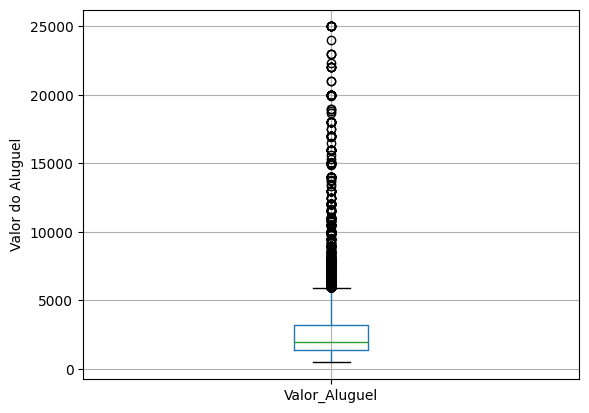

In [6]:
df.boxplot(column='Valor_Aluguel')
plt.ylabel('Valor do Aluguel')
plt.show()

In [7]:
maiores5500 = df[df['Valor_Aluguel'] > 5500]['Valor_Aluguel'].count()
print(maiores5500/len(df['Valor_Aluguel']) * 100)

menores5500 = df[df['Valor_Aluguel'] <= 5500]['Valor_Aluguel'].count()
print(menores5500/len(df['Valor_Aluguel']) * 100)

10.884353741496598
89.1156462585034


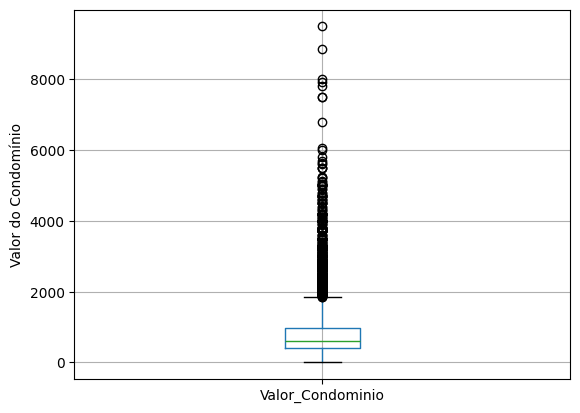

46.46674996529224
53.533250034707756


In [8]:
df.boxplot(column='Valor_Condominio')
plt.ylabel('Valor do Condomínio')
plt.show()

maiores2000 = df[df['Valor_Aluguel'] > 2000]['Valor_Aluguel'].count()
print(maiores2000/len(df['Valor_Aluguel']) * 100)

menores2000 = df[df['Valor_Aluguel'] <= 2000]['Valor_Aluguel'].count()
print(menores2000/len(df['Valor_Aluguel']) * 100)

In [9]:
df.head(5)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0


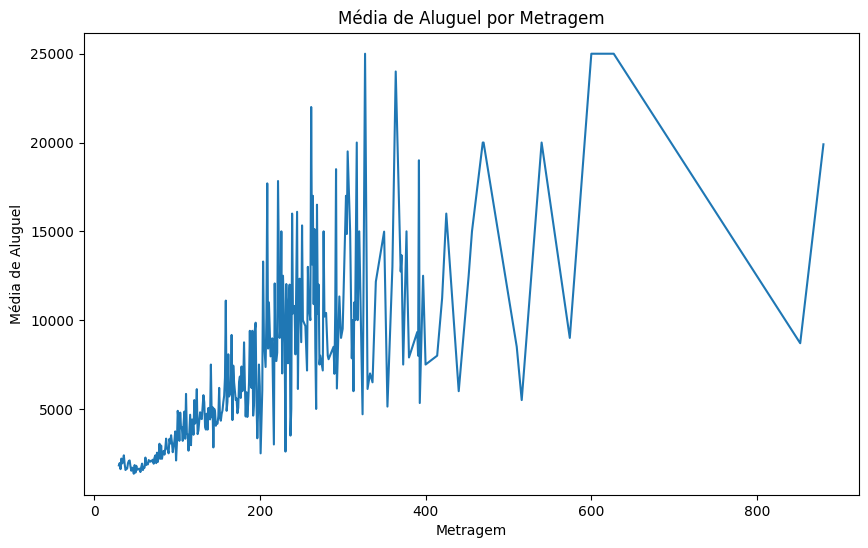

In [10]:

media_aluguel_por_metragem = df.groupby(df['Metragem'])['Valor_Aluguel'].mean() 

media_aluguel_por_metragem = media_aluguel_por_metragem.sort_index() 

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(media_aluguel_por_metragem.index, media_aluguel_por_metragem.values)
ax1.set_xlabel('Metragem')
ax1.set_ylabel('Média de Aluguel')
ax1.set_title('Média de Aluguel por Metragem')
plt.show()

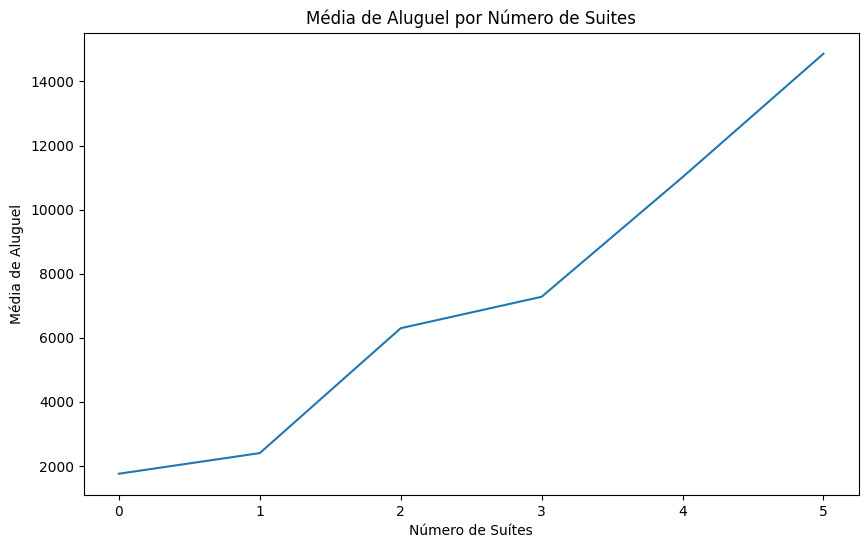

In [11]:

media_aluguel_por_metragem = df.groupby(df['N_Suites'])['Valor_Aluguel'].mean() 

media_aluguel_por_metragem = media_aluguel_por_metragem.sort_index() 

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(media_aluguel_por_metragem.index, media_aluguel_por_metragem.values)
ax1.set_xlabel('Número de Suítes')
ax1.set_ylabel('Média de Aluguel')
ax1.set_title('Média de Aluguel por Número de Suites')
plt.show()

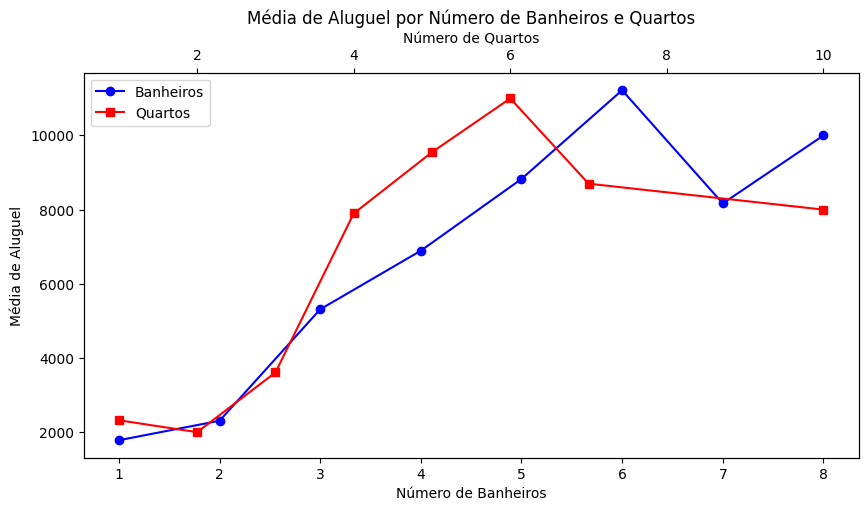

In [12]:
media_aluguel_por_banheiros = df.groupby('N_banheiros')['Valor_Aluguel'].mean().sort_index()
media_aluguel_por_quartos = df.groupby('N_Quartos')['Valor_Aluguel'].mean().sort_index()

fig, ax1 = plt.subplots(figsize=(10, 5))


ax1.plot(media_aluguel_por_banheiros.index, media_aluguel_por_banheiros.values, color='blue', marker='o', label='Banheiros')
ax1.set_xlabel('Número de Banheiros')
ax1.set_ylabel('Média de Aluguel')


ax2 = ax1.twiny()
ax2.plot(media_aluguel_por_quartos.index, media_aluguel_por_quartos.values, color='red', marker='s', label='Quartos')
ax2.set_xlabel('Número de Quartos')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Média de Aluguel por Número de Banheiros e Quartos')
plt.show()

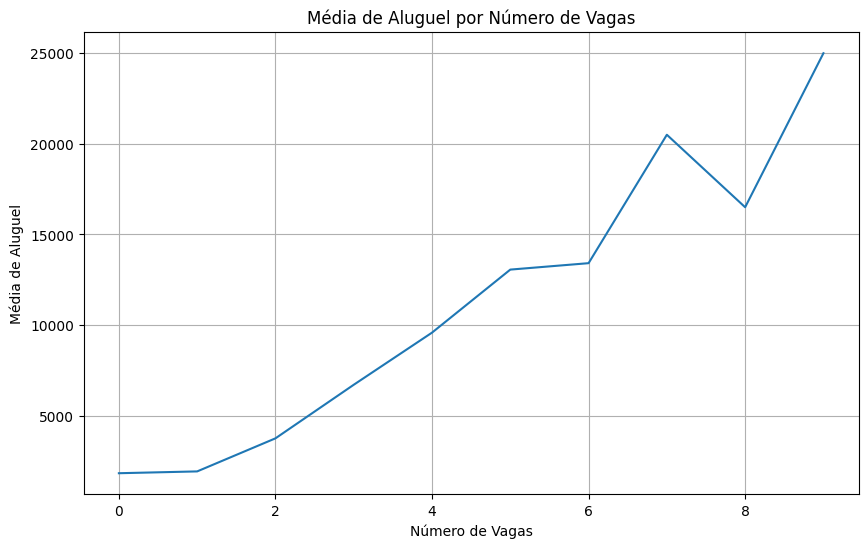

In [13]:

media_vagas_por_metragem = df.groupby(df['N_Vagas'])['Valor_Aluguel'].mean() 

media_vagas_por_metragem = media_vagas_por_metragem.sort_index() 

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(media_vagas_por_metragem.index, media_vagas_por_metragem.values)
ax1.set_xlabel('Número de Vagas')
ax1.set_ylabel('Média de Aluguel')
ax1.set_title('Média de Aluguel por Número de Vagas')
plt.grid()
plt.show()

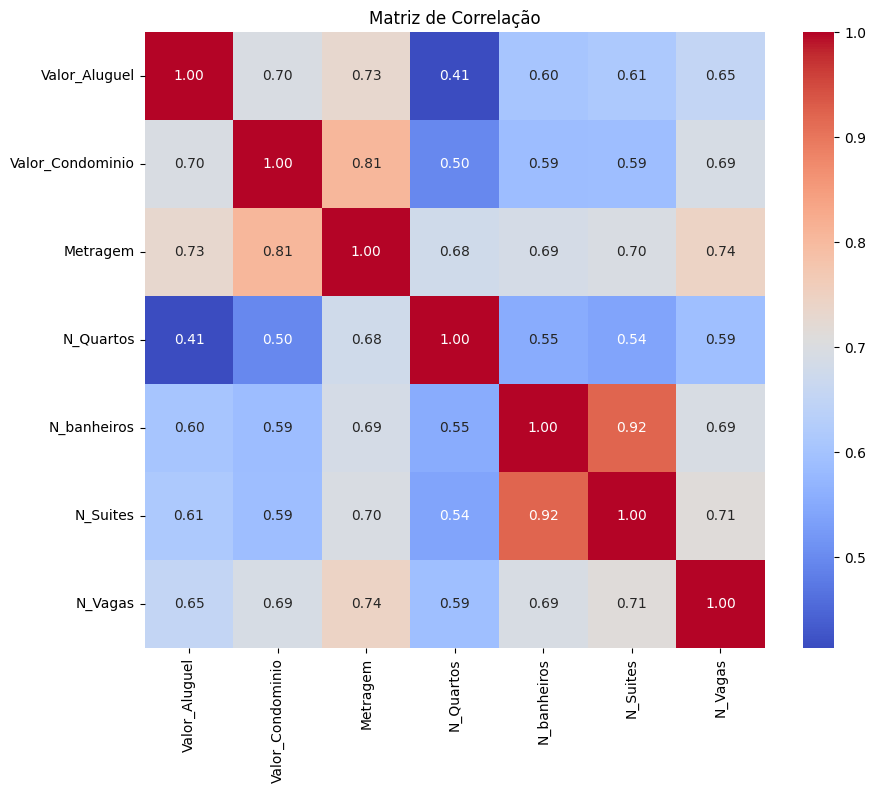

In [14]:
correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 10}) 
plt.title('Matriz de Correlação')
plt.show()

In [15]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)

In [17]:
X_train

,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
6931,1350,176,3,4,3,3
4125,680,70,1,1,0,2
6079,650,66,2,1,0,1
5044,655,68,3,2,1,1
2299,330,33,1,1,0,1
...,...,...,...,...,...,...
3772,450,48,2,2,1,1
5191,570,34,1,1,0,1
5226,976,95,2,2,1,1
5390,550,74,3,3,1,2


In [18]:
X_test

,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
3885,484,50,2,1,0,1
4661,680,50,2,1,0,1
1038,0,58,2,2,1,1
5867,1226,127,3,1,0,2
5099,697,90,4,3,1,2
...,...,...,...,...,...,...
4689,1250,160,3,3,1,2
5313,530,43,1,2,1,1
5624,1250,147,4,4,2,3
4647,650,53,2,1,0,1


In [19]:
y_train

6931    10000
4125     2200
6079     4500
5044     2900
2299     1500
        ...  
3772     2000
5191     3000
5226     3000
5390     3200
860      1100
Name: Valor_Aluguel, Length: 5402, dtype: int64

In [20]:
y_test

3885    2100
4661    2500
1038    1200
5867    4000
5099    3000
        ... 
4689    2550
5313    3100
5624    3500
4647    2500
4453    2500
Name: Valor_Aluguel, Length: 1801, dtype: int64

In [35]:
X = X_train[['Metragem']]  
y = y_train 



In [28]:
regressao_linear = LinearRegression()
regressao_linear.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
regressao_linear.intercept_

np.float64(-103.17820863080169)

In [30]:
regressao_linear.coef_

array([34.70818769])

In [ ]:
regressao_linear.score(X, y)

# Resultado péssimo, o modelo não se encaixa bem aos dados. O R² é muito baixo, indicando que mesmo a variável 'Metragem' tendo alta correlação com o 'Valor_Aluguel', o modelo não consegue capturar a complexidade dos dados.

0.5213271756253639

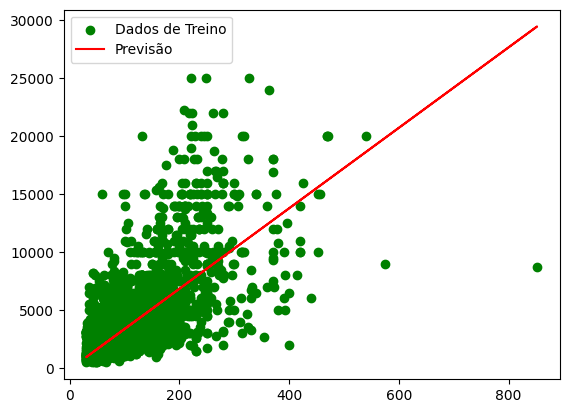

In [32]:
plt.scatter(X,y, color='green', label='Dados de Treino')

plt.plot(X, regressao_linear.predict(X), color='red', label='Previsão')
plt.legend()
plt.show()

In [36]:
X_test = X_test[['Metragem']]  
y_test = y_test  

In [37]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = regressao_linear.predict(X_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2 = regressao_linear.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)


Coeficiente de Determinação (R²) nos Dados de Teste: 0.5651600449476675


Não houve grande alteração do teste pro treino, no treino o resultado foi de 0.52 e no teste 0.56

In [48]:
X = df.drop('Valor_Aluguel', axis=1)
y = df['Valor_Aluguel']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [50]:
X_train

,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
6931,1350,176,3,4,3,3
4125,680,70,1,1,0,2
6079,650,66,2,1,0,1
5044,655,68,3,2,1,1
2299,330,33,1,1,0,1
...,...,...,...,...,...,...
3772,450,48,2,2,1,1
5191,570,34,1,1,0,1
5226,976,95,2,2,1,1
5390,550,74,3,3,1,2


In [51]:
y_train

6931    10000
4125     2200
6079     4500
5044     2900
2299     1500
        ...  
3772     2000
5191     3000
5226     3000
5390     3200
860      1100
Name: Valor_Aluguel, Length: 5402, dtype: int64

In [52]:
X_test

,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
3885,484,50,2,1,0,1
4661,680,50,2,1,0,1
1038,0,58,2,2,1,1
5867,1226,127,3,1,0,2
5099,697,90,4,3,1,2
...,...,...,...,...,...,...
4689,1250,160,3,3,1,2
5313,530,43,1,2,1,1
5624,1250,147,4,4,2,3
4647,650,53,2,1,0,1


In [53]:
y_test

3885    2100
4661    2500
1038    1200
5867    4000
5099    3000
        ... 
4689    2550
5313    3100
5624    3500
4647    2500
4453    2500
Name: Valor_Aluguel, Length: 1801, dtype: int64

In [54]:
X = X_train[['Valor_Condominio','Metragem', 'N_Quartos', 'N_banheiros', 'N_Suites', 'N_Vagas']]
y = y_train

In [55]:
regressao_multipla = LinearRegression()
regressao_multipla.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
regressao_multipla.intercept_

np.float64(411.9289507738454)

In [57]:
regressao_multipla.coef_

array([   0.77302112,   20.72122898, -659.00604215,  240.76046013,
        340.61447028,  522.98401929])

In [58]:
regressao_multipla.score(X, y)

0.5971610197647366

In [59]:
X = X_train[['Valor_Condominio','Metragem', 'N_Quartos', 'N_banheiros', 'N_Suites', 'N_Vagas']]
y = y_train

In [62]:
previsoes = regressao_multipla.predict(X_test)

r2 = regressao_multipla.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)

Coeficiente de Determinação (R²) nos Dados de Teste: 0.6327633459161507
